In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = "localhost",
                             username = "root", 
                             password = "Ushaammu@1617",
                             database = "ecommerce")
cur = db.cursor()

# 1. List all unique cities where customers are located.

In [28]:
query = """ select distinct(customer_city) from customers """

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# 2. Count the number of orders placed in 2017.

In [7]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()

"Total orders placed in 2017 are",data[0][0]

('Total orders placed in 2017 are', 45101)

# 3. Find the total sales per category.

In [11]:
query = """ select Upper(products.product_category_name) category,
round(sum(payments.payment_value),2)sales
from products join order_items 
on products.product_id = order_items.product_id 
join payments 
on payments.order_id = order_items.order_id
group by category
"""

cur.execute(query)

data = cur.fetchall()

df =pd.DataFrame(data, columns = ["Category", "Sales"])
df

,Category,Sales
0,PERFUMARIA,4053909.28
1,MOVEIS_DECORACAO,11441411.13
2,TELEFONIA,3895056.41
3,FASHION_BOLSAS_E_ACESSORIOS,1745266.24
4,CAMA_MESA_BANHO,13700429.37
...,...,...
69,CDS_DVDS_MUSICAIS,9595.44
70,LA_CUISINE,23308.24
71,FASHION_ROUPA_INFANTO_JUVENIL,6285.36
72,PC_GAMER,17395.44


# 4. Calculate the percentage of orders that were paid in installments.

In [15]:
query = """ select (sum(case when payment_installments >= 1 then 1 else 0 end ))/count(*)*100 from payments
"""
cur.execute(query)

data = cur.fetchall()
"The percentage of orders that were paid in installments is", data[0][0]

('The percentage of orders that were paid in installments is',
 Decimal('99.9981'))

# 5. Count the number of customers from each state. 

<function matplotlib.pyplot.show(close=None, block=None)>

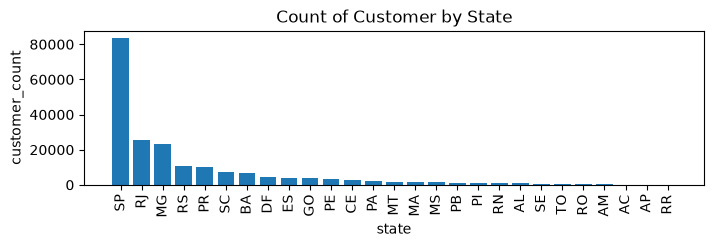

In [10]:
query = """ select customer_state, count(customer_id)
from customers group by customer_state
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["state", "customer_count"])
df = df.sort_values(by = "customer_count",ascending = False)

plt.figure(figsize = (8,2))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation = 90)
plt.xlabel("state")
plt.ylabel("customer_count")
plt.title("Count of Customer by State")
plt.show

# 6.Calculate the number of orders per month in 2018.

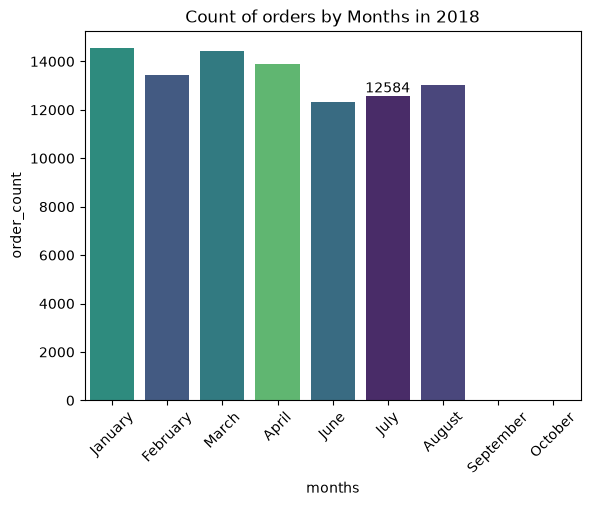

In [18]:
query = """ select monthname(order_purchase_timestamp) months,count(order_id)
from orders where (order_purchase_timestamp) = 2018
group by months
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data ,columns = ["months","order_count"])
o =["January", "February","March","April","June","July","August","September","October"]

ax = sns.barplot(x = df["months"],y= df["order_count"], data = df, order =o , hue = df["months"] , palette = "viridis")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of orders by Months in 2018")

plt.show()

# 7. Find the average number of products per order, grouped by customer city.

In [25]:
query = """ with count_per_order as 
(select orders.order_id , orders.customer_id, count(order_items.order_id) as oc
from orders join order_items 
on orders.order_id = order_items.order_id
group by orders.order_id,orders.customer_id)

select customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order 
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data , columns = ["customer city" , "average orders"])
df.head(10)

,customer city,average orders
0,padre carvalho,28.00
1,celso ramos,26.00
2,datas,24.00
3,candido godoi,24.00
4,matias olimpio,20.00
5,cidelandia,16.00
6,curralinho,16.00
7,picarra,16.00
8,morro de sao paulo,16.00
9,teixeira soares,16.00


# 8. Calculate the percentage of total revenue contributed by each product category.

In [27]:
query = """ select Upper(products.product_category_name) category,
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2)sales_percentage
from products join order_items 
on products.product_id = order_items.product_id 
join payments 
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data ,columns = ["Category","Percentage_distribution"])
df.head(10)

,Category,Percentage_distribution
0,CAMA_MESA_BANHO,42.79
1,BELEZA_SAUDE,41.41
2,INFORMATICA_ACESSORIOS,39.61
3,MOVEIS_DECORACAO,35.73
4,RELOGIOS_PRESENTES,35.71
5,ESPORTE_LAZER,34.78
6,UTILIDADES_DOMESTICAS,27.35
7,AUTOMOTIVO,21.30
8,FERRAMENTAS_JARDIM,20.95
9,COOL_STUFF,19.48


# 9. Identify the correlation between product price and the number of times a product has been purchased.

In [8]:
import numpy as np
query = """ select products.product_category_name, 
count(order_items.product_id),
round(avg(order_items.price),2) 
from products join order_items 
on products.product_id = order_items.product_id
group by products.product_category_name
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Category", "Order_count", "Price"])

arr1 = df["Order_count"]
arr2 = df["Price"]

a = np.corrcoef([arr1,arr2])
print("The correlation between price and number of times a product has been purchased is",a[0][1])

The correlation between price and number of times a product has been purchased is -0.10631514167157562


# 10. Calculate the total revenue generated by each seller, and rank them by revenue.

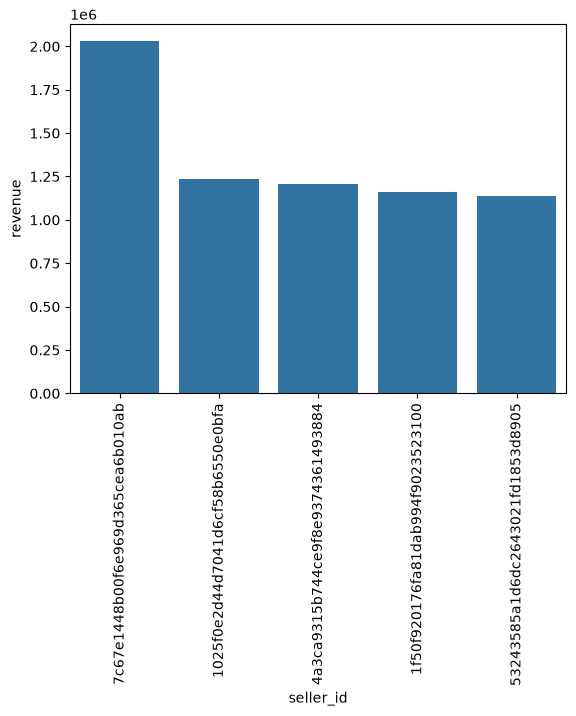

In [24]:
query = """ select *, dense_rank() over( order by revenue desc) as rn from
(select order_items.seller_id, sum(payments.payment_value)
revenue from order_items join payments 
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["seller_id", "revenue", "rank"])
df = df.head(5)
sns.barplot(x = "seller_id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# 11. Calculate the moving average of order values for each customer over their order history.

In [28]:
query = """ select customer_id, order_purchase_timestamp, payment,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row)as mov_avg 
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders
on payments.order_id = orders.order_id)as a
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["customer_id", "time", "payment","mov_avg"])
df.head(10)

,customer_id,time,payment,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
5,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
6,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
7,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
8,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
9,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998


# 12. Calculate the cumulative sales per month for each year.

In [2]:
query = """ select years, months, payment ,sum(payment)
over(order by years, months )cumulative_sales from 
(select year(orders.order_purchase_timestamp) as years ,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value), 2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years, months order by years, months) as a
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "months", "payment","cumulative_sales"])
df.head(10)

,years,months,payment,cumulative_sales
0,2016,9,1008.96,1008.96
1,2016,10,236361.92,237370.88
2,2016,12,78.48,237449.36
3,2017,1,553952.16,791401.52
4,2017,2,1167632.04,1959033.56
5,2017,3,1799454.40,3758487.96
6,2017,4,1671152.12,5429640.08
7,2017,5,2371675.28,7801315.36
8,2017,6,2045105.52,9846420.88
9,2017,7,2369531.68,12215952.56


# 13. Calculate the year-over-year growth rate of total sales.

In [13]:
query = """ with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value), 2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment -lag(payment, 1) over(order by years ))/lag(payment, 1) over(order by years ))*100 from a"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data , columns = ["years","yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703757
2,2018,20.000924


# 14. Calculate the retention rate of customers,defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [14]:
query = """ with a as(select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders 
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp)
from a join orders 
on orders.customer_id = a.customer_id and orders.order_purchase_timestamp > first_order 
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month) group by a.customer_id)

select 100* (count(distinct a.customer_id)/ count(distinct b.customer_id))
from a left join b
on a.customer_id = b.customer_id
"""
cur.execute(query)

data = cur.fetchall()
data

[(None,)]

# 15. Identify the top 3 customers who spent the most money in each year.

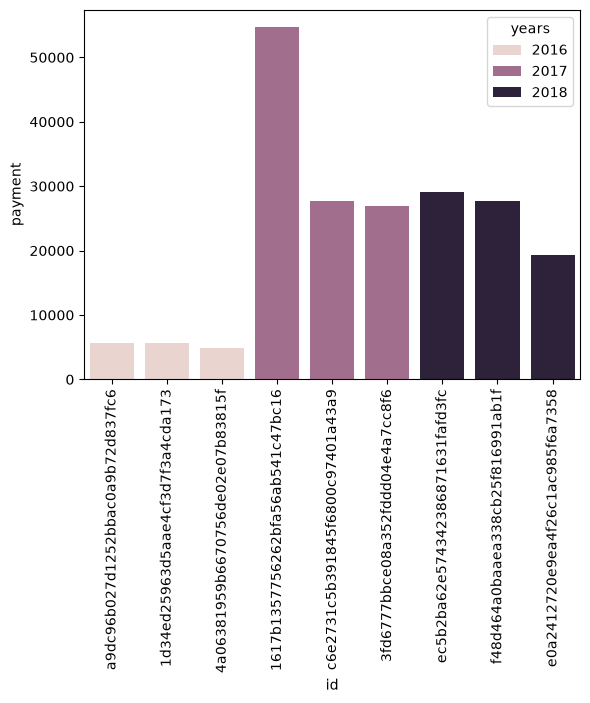

In [22]:
query = """ select years, customer_id, payment, d_rank 
from 
(select year(orders.order_purchase_timestamp) years,
orders.customer_id,
sum(payments.payment_value) payment,
dense_rank() over (partition by year(orders.order_purchase_timestamp) 
order by sum(payments.payment_value) desc)d_rank
from orders join payments 
on orders.order_id = payments.order_id
group by year(orders.order_purchase_timestamp), orders.customer_id) as a
where d_rank <= 3 ;
"""
cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payment","rank"])
sns.barplot(x = "id", y = "payment", data = df , hue = "years")
plt.xticks(rotation =90)
plt.show()